## 1. Install dependencies

In [ ]:
!pip install kaggle pandas numpy matplotlib seaborn --quiet
print('✅ Dependencies installed')

✅ Dependencies installed


In [ ]:
from google.colab import files
import os, json

print('Upload your kaggle.json file:')
uploaded = files.upload()

os.makedirs('/root/.config/kaggle', exist_ok=True)
with open('/root/.config/kaggle/kaggle.json', 'w') as f:
    f.write(list(uploaded.values())[0].decode())
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print('✅ Kaggle API configured')

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
✅ Kaggle API configured


## 2. Download datasets from Kaggle

In [ ]:
import os

os.makedirs('data/raw', exist_ok=True)

# Dataset 1: International football results (47k+ matches, 1872-2024)
# https://www.kaggle.com/datasets/martj42/international-football-results
print('Downloading international match results...')
!kaggle datasets download -d martj42/international-football-results -p data/raw --unzip -q

# Dataset 2: FIFA rankings history
# https://www.kaggle.com/datasets/cashncarry/fifaworldranking
print('Downloading FIFA rankings history...')
!kaggle datasets download -d cashncarry/fifaworldranking -p data/raw --unzip -q

print('\n✅ Downloads complete. Files:')
for f in os.listdir('data/raw'):
    size = os.path.getsize(f'data/raw/{f}') / 1024
    print(f'  {f:40s} {size:7.1f} KB')

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
Dataset URL: https://www.kaggle.com/datasets/cashncarry/fifaworldranking
License(s): CC0-1.0

✅ Downloads complete. Files:
  fifa_ranking-2024-04-04.csv               3257.1 KB
  fifa_ranking-2024-06-20.csv               2893.7 KB
  fifa_ranking-2023-07-20.csv               2769.4 KB


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("martj42/international-football-results-from-1872-to-2017")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'international-football-results-from-1872-to-2017' dataset.
Path to dataset files: /kaggle/input/international-football-results-from-1872-to-2017


## 3. Load and inspect raw data

In [ ]:
import pandas as pd
import numpy as np

# ── Match results ──────────────────────────────────────────
# Columns: date, home_team, away_team, home_score, away_score,
#          tournament, city, country, neutral
matches = pd.read_csv('/kaggle/input/international-football-results-from-1872-to-2017/results.csv', parse_dates=['date'])

print('=== MATCH RESULTS ===')
print(f'Shape: {matches.shape}')
print(f'Date range: {matches.date.min().date()} → {matches.date.max().date()}')
print(f'Unique teams: {pd.unique(matches[["home_team","away_team"]].values.ravel()).shape[0]}')
print(f'Null values:\n{matches.isnull().sum()}\n')
matches.head(3)

=== MATCH RESULTS ===
Shape: (49477, 9)
Date range: 1872-11-30 → 2026-06-27
Unique teams: 336
Null values:
date           0
home_team      0
away_team      0
home_score    44
away_score    44
tournament     0
city           0
country        0
neutral        0
dtype: int64



,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False


In [ ]:
# ── FIFA Rankings ──────────────────────────────────────────
# Columns: rank_date, country_full, rank, total_points, ...
import glob

# Find the rankings file (name varies by dataset version)
ranking_files = glob.glob('data/raw/*ranking*') + glob.glob('data/raw/*fifa*')
ranking_file = ranking_files[0] if ranking_files else 'data/raw/fifa_ranking-2023-06-22.csv'
print(f'Using rankings file: {ranking_file}')

rankings = pd.read_csv(ranking_file, parse_dates=['rank_date'])

print('\n=== FIFA RANKINGS ===')
print(f'Shape: {rankings.shape}')
print(f'Date range: {rankings.rank_date.min().date()} → {rankings.rank_date.max().date()}')
print(f'Columns: {list(rankings.columns)}')
rankings.head(3)

Using rankings file: data/raw/fifa_ranking-2024-04-04.csv

=== FIFA RANKINGS ===
Shape: (67261, 8)
Date range: 1992-12-31 → 2024-04-04
Columns: ['rank', 'country_full', 'country_abrv', 'total_points', 'previous_points', 'rank_change', 'confederation', 'rank_date']


,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
0,83.0,Guatemala,GUA,15.0,0.0,83,CONCACAF,1992-12-31
1,32.0,Zambia,ZAM,38.0,0.0,32,CAF,1992-12-31
2,33.0,Portugal,POR,38.0,0.0,33,UEFA,1992-12-31


## 4. Clean match results

In [ ]:
df = matches.copy()

# ── 5.1 Filter to meaningful competitions (drop friendlies pre-1990, keep WC/QF/continental) ──
KEEP_ALL_AFTER = '1993-01-01'   # Keep all tournaments after this
KEEP_ALWAYS = ['FIFA World Cup', 'UEFA Euro', 'Copa América', 'AFC Asian Cup',
               'Africa Cup of Nations', 'CONCACAF Gold Cup', 'UEFA Nations League',
               'Copa América Centenario', 'Confederations Cup']

mask_date  = df['date'] >= KEEP_ALL_AFTER
mask_tourn = df['tournament'].isin(KEEP_ALWAYS)
df = df[mask_date | mask_tourn].copy()
print(f'After tournament/date filter: {len(df):,} rows (was {len(matches):,})')

# ── 5.2 Drop rows with missing scores ──
df = df.dropna(subset=['home_score', 'away_score'])

# ── 5.3 Cast scores to int ──
df['home_score'] = df['home_score'].astype(int)
df['away_score'] = df['away_score'].astype(int)

# ── 5.4 Add outcome label (target variable) ──
# H = home win, D = draw, A = away win
def get_outcome(row):
    if row['home_score'] > row['away_score']: return 'H'
    if row['home_score'] < row['away_score']: return 'A'
    return 'D'

df['outcome'] = df.apply(get_outcome, axis=1)

# ── 5.5 Add is_world_cup flag ──
df['is_world_cup'] = df['tournament'] == 'FIFA World Cup'

# ── 5.6 Add is_knockout flag (non-group WC matches, finals etc.) ──
KNOCKOUT_KEYWORDS = ['final', 'semi', 'quarter', 'round of', 'knockout']
# (Not in this dataset directly, but we flag WC for now)
df['is_neutral'] = df['neutral'].astype(bool)

print(f'\nOutcome distribution:')
print(df['outcome'].value_counts(normalize=True).round(3))
print(f'\nWorld Cup matches: {df["is_world_cup"].sum():,}')
print(f'\nTop tournaments:')
print(df['tournament'].value_counts().head(10))

After tournament/date filter: 31,973 rows (was 49,477)

Outcome distribution:
outcome
H    0.486
A    0.282
D    0.232
Name: proportion, dtype: float64

World Cup matches: 992

Top tournaments:
tournament
Friendly                                10211
FIFA World Cup qualification             6821
UEFA Euro qualification                  1991
African Cup of Nations qualification     1745
FIFA World Cup                            992
Copa América                              869
UEFA Nations League                       658
AFC Asian Cup qualification               613
African Cup of Nations                    606
CFU Caribbean Cup qualification           453
Name: count, dtype: int64


## 5. Clean and standardise FIFA rankings

In [ ]:
rk = rankings.copy()

# Standardise column names
rk.columns = rk.columns.str.strip().str.lower().str.replace(' ','_')

# Keep only what we need
rk = rk[['rank_date', 'country_full', 'rank', 'total_points']].copy()
rk.columns = ['date', 'team', 'fifa_rank', 'fifa_points']
rk = rk.sort_values('date').reset_index(drop=True)

# ── Name standardisation: align team names between datasets ──
NAME_MAP = {
    'IR Iran':          'Iran',
    'Korea Republic':   'South Korea',
    'Korea DPR':        'North Korea',
    'USA':              'United States',
    'Türkiye':          'Turkey',
    'Czechia':          'Czech Republic',
    'China PR':         'China',
    'Côte d\'Ivoire':  'Ivory Coast',
    'Bosnia-Herzegovina': 'Bosnia and Herzegovina',
    'Cabo Verde':       'Cape Verde',
    'Curaçao':          'Curacao',
    'Trinidad and Tobago': 'Trinidad & Tobago',
}
rk['team'] = rk['team'].replace(NAME_MAP)

print(f'Rankings shape: {rk.shape}')
print(f'Date range: {rk.date.min().date()} → {rk.date.max().date()}')
print(f'Unique teams: {rk.team.nunique()}')
rk.head(5)

Rankings shape: (67261, 4)
Date range: 1992-12-31 → 2024-04-04
Unique teams: 216


,date,team,fifa_rank,fifa_points
0,1992-12-31,Guatemala,83.0,15.0
1,1992-12-31,Sierra Leone,79.0,16.0
2,1992-12-31,Tanzania,80.0,15.0
3,1992-12-31,Niger,81.0,15.0
4,1992-12-31,Iraq,82.0,15.0


## 6. Merge rankings into match data

For each match, we look up the FIFA ranking **closest to but before** the match date for both teams.
This is an `asof` merge — it prevents data leakage (we never use rankings published after the match).

In [ ]:
def get_ranking_at_date(team_name, match_date, rankings_df):
    """Return FIFA rank and points for a team at (or just before) match_date."""
    team_rk = rankings_df[rankings_df['team'] == team_name]
    past    = team_rk[team_rk['date'] <= match_date]
    if past.empty:
        return None, None
    row = past.iloc[-1]  # most recent before match
    return row['fifa_rank'], row['fifa_points']

# Build a lookup dict for speed: team → sorted (date, rank, points) records
rk_lookup = {}
for team, grp in rk.groupby('team'):
    rk_lookup[team] = grp.sort_values('date')[['date','fifa_rank','fifa_points']].values

def fast_lookup(team, match_date):
    if team not in rk_lookup:
        return np.nan, np.nan
    records = rk_lookup[team]
    # binary search for last date <= match_date
    dates = records[:, 0]
    idx = np.searchsorted(dates, match_date, side='right') - 1
    if idx < 0:
        return np.nan, np.nan
    return float(records[idx, 1]), float(records[idx, 2])

print('Merging rankings into matches (this takes ~30s)...')
home_ranks  = [fast_lookup(row.home_team, row.date) for row in df.itertuples()]
away_ranks  = [fast_lookup(row.away_team, row.date) for row in df.itertuples()]

df['home_fifa_rank']   = [r[0] for r in home_ranks]
df['home_fifa_points'] = [r[1] for r in home_ranks]
df['away_fifa_rank']   = [r[0] for r in away_ranks]
df['away_fifa_points'] = [r[1] for r in away_ranks]

# Rank difference (positive = home team ranked better)
df['rank_diff']   = df['away_fifa_rank']   - df['home_fifa_rank']    # +ve → home favoured
df['points_diff'] = df['home_fifa_points'] - df['away_fifa_points']  # +ve → home favoured

# How many matches have ranking data?
has_rank = df['home_fifa_rank'].notna() & df['away_fifa_rank'].notna()
print(f'\nMatches with FIFA ranking data: {has_rank.sum():,} / {len(df):,} ({100*has_rank.mean():.1f}%)')
df[has_rank][['date','home_team','away_team','rank_diff','points_diff','outcome']].head(5)

Merging rankings into matches (this takes ~30s)...

Matches with FIFA ranking data: 26,633 / 31,929 (83.4%)


,date,home_team,away_team,rank_diff,points_diff,outcome
18708,1993-01-01,Ghana,Mali,30.0,12.0,D
18709,1993-01-02,Gabon,Burkina Faso,42.0,16.0,D
18710,1993-01-02,Kuwait,Lebanon,90.0,21.0,H
18711,1993-01-03,Burkina Faso,Mali,-28.0,-11.0,H
18712,1993-01-03,Gabon,Ghana,-16.0,-7.0,A


## 7. Dataset overview and quality checks

/tmp/ipykernel_1667/3744479557.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(outcomes.values(), labels=['Home Win','Draw','Away Win'],


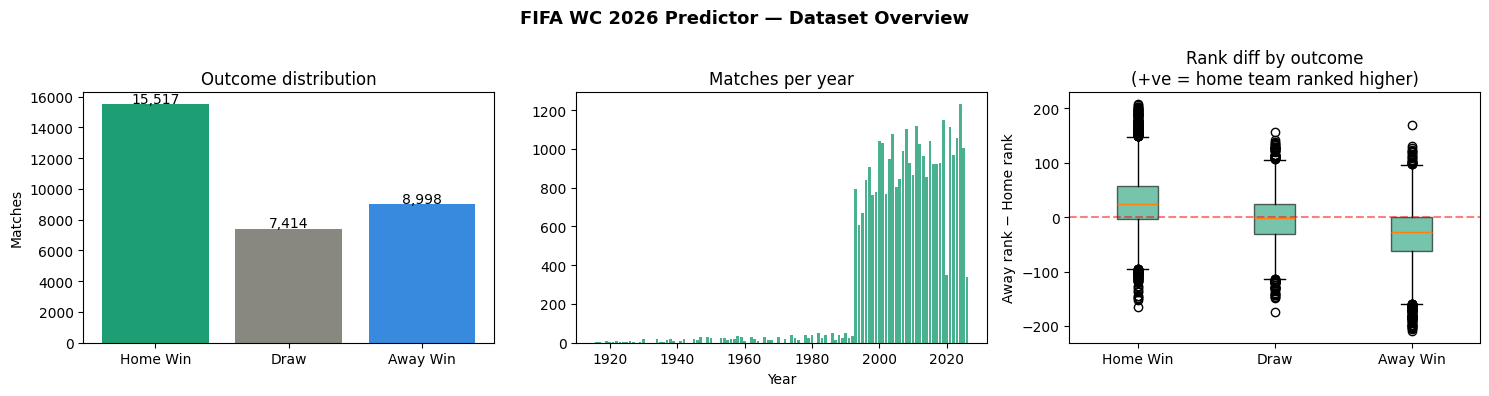


✅ Chart saved to data/dataset_overview.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('FIFA WC 2026 Predictor — Dataset Overview', fontsize=13, fontweight='bold')

# Plot 1: Outcome distribution
counts = df['outcome'].value_counts()[['H','D','A']]
axes[0].bar(['Home Win','Draw','Away Win'], counts.values, color=['#1D9E75','#888780','#378ADD'])
axes[0].set_title('Outcome distribution')
axes[0].set_ylabel('Matches')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=10)

# Plot 2: Matches per year
df['year'] = df['date'].dt.year
per_year = df.groupby('year').size()
axes[1].bar(per_year.index, per_year.values, color='#1D9E75', alpha=0.8)
axes[1].set_title('Matches per year')
axes[1].set_xlabel('Year')

# Plot 3: Rank diff vs outcome (box)
ranked = df[df['rank_diff'].notna()]
outcomes = {'H': ranked[ranked.outcome=='H']['rank_diff'],
            'D': ranked[ranked.outcome=='D']['rank_diff'],
            'A': ranked[ranked.outcome=='A']['rank_diff']}
axes[2].boxplot(outcomes.values(), labels=['Home Win','Draw','Away Win'],
                patch_artist=True,
                boxprops=dict(facecolor='#1D9E75', alpha=0.6))
axes[2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('Rank diff by outcome\n(+ve = home team ranked higher)')
axes[2].set_ylabel('Away rank − Home rank')

plt.tight_layout()
plt.savefig('data/dataset_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('\n✅ Chart saved to data/dataset_overview.png')

In [ ]:
# Final null check before export
print('=== NULL CHECK ===')
print(df.isnull().sum())
print(f'\nFinal shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

=== NULL CHECK ===
date                   0
home_team              0
away_team              0
home_score             0
away_score             0
tournament             0
city                   0
country                0
neutral                0
outcome                0
is_world_cup           0
is_neutral             0
home_fifa_rank      3712
home_fifa_points    3709
away_fifa_rank      3991
away_fifa_points    3985
rank_diff           5296
points_diff         5290
year                   0
dtype: int64

Final shape: (31929, 19)
Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'outcome', 'is_world_cup', 'is_neutral', 'home_fifa_rank', 'home_fifa_points', 'away_fifa_rank', 'away_fifa_points', 'rank_diff', 'points_diff', 'year']


## 8. Export clean dataset

In [ ]:
import os
os.makedirs('data/processed', exist_ok=True)

# ── Full clean dataset ──
df.to_csv('data/processed/matches_clean.csv', index=False)

# ── WC-only subset (for inspection / WC-specific model later) ──
wc_only = df[df['is_world_cup']]
wc_only.to_csv('data/processed/worldcup_matches.csv', index=False)

# ── Clean rankings ──
rk.to_csv('data/processed/rankings_clean.csv', index=False)

print('=== EXPORT SUMMARY ===')
print(f'matches_clean.csv   → {len(df):,} rows, {df.shape[1]} columns')
print(f'worldcup_matches.csv → {len(wc_only):,} World Cup matches only')
print(f'rankings_clean.csv  → {len(rk):,} ranking snapshots')
print()
print('Columns in matches_clean.csv:')
for col in df.columns:
    dtype = str(df[col].dtype)
    nulls = df[col].isnull().sum()
    print(f'  {col:30s} {dtype:12s} nulls={nulls}')

print('\n✅ All files saved to data/processed/')
print('\n➡️  Next: open 02_feature_engineering.ipynb')

=== EXPORT SUMMARY ===
matches_clean.csv   → 31,929 rows, 19 columns
worldcup_matches.csv → 992 World Cup matches only
rankings_clean.csv  → 67,261 ranking snapshots

Columns in matches_clean.csv:
  date                           datetime64[ns] nulls=0
  home_team                      object       nulls=0
  away_team                      object       nulls=0
  home_score                     int64        nulls=0
  away_score                     int64        nulls=0
  tournament                     object       nulls=0
  city                           object       nulls=0
  country                        object       nulls=0
  neutral                        bool         nulls=0
  outcome                        object       nulls=0
  is_world_cup                   bool         nulls=0
  is_neutral                     bool         nulls=0
  home_fifa_rank                 float64      nulls=3712
  home_fifa_points               float64      nulls=3709
  away_fifa_rank                 float6

In [ ]:
# Uncomment and run if you want to save to Drive

# from google.colab import drive
# drive.mount('/content/drive')
#
# import shutil
# dest = '/content/drive/MyDrive/wc26_predictor/data/processed'
# os.makedirs(dest, exist_ok=True)
# shutil.copy('data/processed/matches_clean.csv', dest)
# shutil.copy('data/processed/worldcup_matches.csv', dest)
# shutil.copy('data/processed/rankings_clean.csv', dest)
# print(f'✅ Saved to Google Drive: {dest}')